# MACE-MDP IR Tutorial

This notebook presents an end-to-end **MACE-MDP** infrared (IR) workflow for a single molecule using the first structure in the example XYZ dataset.


## Scientific context

IR spectroscopy measures vibrational transitions that change the molecular dipole moment.

The computational pieces are:

- Energy Hessian with respect to Cartesian coordinates:
  $$H_{ij}=\frac{\partial^2 E}{\partial R_i\partial R_j}$$
- Mass-weighted normal mode eigenproblem:
  $$M^{-1/2}HM^{-1/2}\mathbf{e}_k=\omega_k^2\mathbf{e}_k$$
- Wavenumber conversion:
  $$\tilde\nu_k=\frac{\omega_k}{2\pi c}$$
- IR activity along normal coordinate $Q_k$:
  $$I_k\propto\left\|\frac{\partial\boldsymbol\mu}{\partial Q_k}\right\|^2$$

Here, all model predictions are evaluated with **MACE-MDP assets in this repository**.


## Workflow and files used

- Input structure file: `examples/mini_database_IR-R-7193_wB97MD3.xyz`
- Demonstration structure: first frame (`index=0`)
- Model path used in this notebook: `../models/MACE-MDP.model`
- Output folder created by this notebook: `examples/IR/results`


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase.io import read
from ase import units
from ase.optimize import BFGS
from mace.calculators.mace import MACECalculator
from mace.calculators import mace_off


/work/mace_alpha_venv/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


## Step 1: Load the first example structure


In [2]:
xyz_path = "../mini_database_IR-R-7193_wB97MD3.xyz"
model_path = "../../models/MACE-MDP.model"

atoms = read(xyz_path, index=0)

## Step 2: Build calculators and optimize geometry

We use two model components:
- `mace_off(model="small")` for optimization and Hessian evaluation,
- `MACECalculator(..., model_type="DipolePolarizabilityMACE")` for dipole predictions needed for IR intensities (using the same MACE-MDP model family).

After attaching `off_calc` to the atoms object, BFGS relaxes the structure to the target force threshold (`fmax=0.002`). This keeps the vibrational analysis close to a local minimum where frequencies are physically meaningful.


In [3]:
device = "cpu"  # change to "cuda" if your environment supports it

off_calc = mace_off(model="small", default_dtype="float64", device=device)
dipole_calc = MACECalculator(
    model_paths=model_path,
    model_type="DipolePolarizabilityMACE",
    device=device,
    default_dtype="float64",
)

atoms = atoms.copy()
atoms.calc = off_calc

optimizer = BFGS(atoms, logfile=None)
optimizer.run(fmax=0.002, steps=5000)
print("Geometry optimization finished.")


Using MACE-OFF23 MODEL for MACECalculator with /home/ngoen/.cache/mace/MACE-OFF23_small.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/work/mace_alpha_venv/lib/python3.11/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/work/mace_alpha_venv/lib/python3.11/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Geometry optimization finished.


## Step 3: Compute frequencies and normal modes from the Hessian

From the optimized geometry, we compute the Hessian and enforce symmetry with $(H+H^T)/2$. Then we mass-weight and diagonalize to obtain normal modes and squared angular frequencies.

The resulting `freq_cm1` array provides vibrational frequencies in cm$^{-1}$, and `modes` stores displacement patterns used in the IR intensity step.


In [4]:
n_atoms = len(atoms)
masses = atoms.get_masses()

H = off_calc.get_hessian(atoms).reshape(3 * n_atoms, 3 * n_atoms)
H = 0.5 * (H + H.T)  # enforce symmetry

mw = np.repeat(masses ** -0.5, 3)
Hmw = (H * mw).T * mw
omega2, vecs = np.linalg.eigh(Hmw)

conv = units._hbar * units.m / np.sqrt(units._e * units._amu)
energies = conv * np.sqrt(np.abs(omega2))
freq_cm1 = np.real(energies) / units.invcm

modes = vecs.T.reshape(3 * n_atoms, n_atoms, 3)
modes *= masses[np.newaxis, :, np.newaxis] ** -0.5

print("Lowest 12 frequencies (cm^-1):")
print(np.round(freq_cm1[:12], 2))


Lowest 12 frequencies (cm^-1):
[3.7100e+00 1.5200e+00 0.0000e+00 0.0000e+00 0.0000e+00 3.2000e-01
 5.7810e+01 1.0100e+02 1.9932e+02 2.8428e+02 3.1970e+02 3.3460e+02]


## Step 4: Compute IR stick intensities by finite differences

For each normal mode $k$, we displace coordinates by $\pm\Delta Q_k$, evaluate dipoles, and use a central finite difference:

$$\frac{\partial\boldsymbol{\mu}}{\partial Q_k}\approx\frac{\boldsymbol{\mu}(Q_k+\Delta Q_k)-\boldsymbol{\mu}(Q_k-\Delta Q_k)}{2\Delta Q_k}$$

The IR stick intensity is then estimated as:

$$I_k\propto\left\|\frac{\partial\boldsymbol{\mu}}{\partial Q_k}\right\|^2$$

Very low-frequency modes are filtered in the code to suppress translational/rotational artifacts.


In [5]:
intensities = []
pos0 = atoms.get_positions().copy()
step = 1e-3

for mode_idx, mode in enumerate(modes):
    dpos = mode * step

    atoms.set_positions(pos0 + dpos)
    mu_plus = dipole_calc.get_property("dipole", atoms)

    atoms.set_positions(pos0 - dpos)
    mu_minus = dipole_calc.get_property("dipole", atoms)

    atoms.set_positions(pos0)

    dmu_dq = (mu_plus - mu_minus) / (2.0 * step)
    intensity = np.linalg.norm(dmu_dq) ** 2

    if freq_cm1[mode_idx] < 5.0:
        intensity = 0.0

    intensities.append(intensity)

intensities = np.array(intensities)
print("Computed stick intensities for all modes.")


Computed stick intensities for all modes.


## Step 5: Save and inspect raw stick-spectrum output

This step writes the direct mode-wise output (`frequency_cm1`, `intensity`) to CSV and plots the stick spectrum.

Use this view to identify which discrete normal modes contribute the strongest IR response before any broadening is applied.


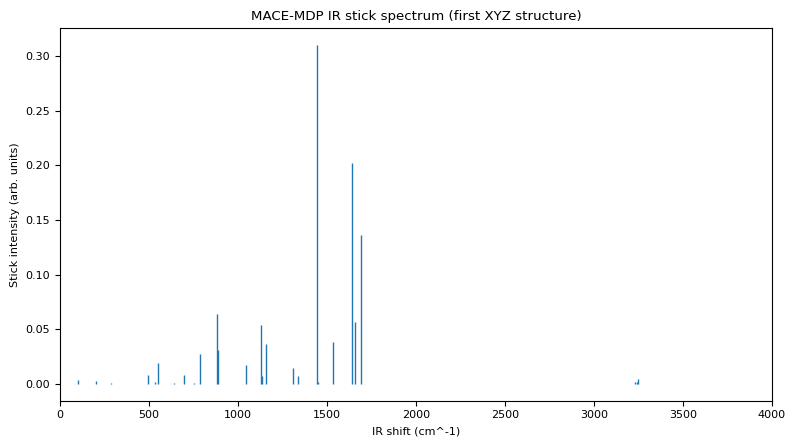

Wrote raw sticks: IR/results/first_structure_ir_raw.csv


In [6]:
out_dir = "IR/results"
os.makedirs(out_dir, exist_ok=True)

raw_path = f"{out_dir}/first_structure_ir_raw.csv"
pd.DataFrame({"frequency_cm1": freq_cm1, "intensity": intensities}).to_csv(raw_path, index=False)

plt.figure(figsize=(8, 4.5))
plt.vlines(freq_cm1, 0.0, intensities, lw=1.0)
plt.xlim(0, 4000)
plt.xlabel("IR shift (cm^-1)")
plt.ylabel("Stick intensity (arb. units)")
plt.title("MACE-MDP IR stick spectrum (first XYZ structure)")
plt.tight_layout()
plt.show()

print(f"Wrote raw sticks: {raw_path}")


## Step 6 (final): Apply Lorentzian broadening for a smooth spectrum

Lorentzian broadening converts discrete sticks into a continuous-looking spectrum using a chosen FWHM.

This is post-processing for visualization/comparison only. The raw frequencies and stick intensities remain the primary computed quantities.


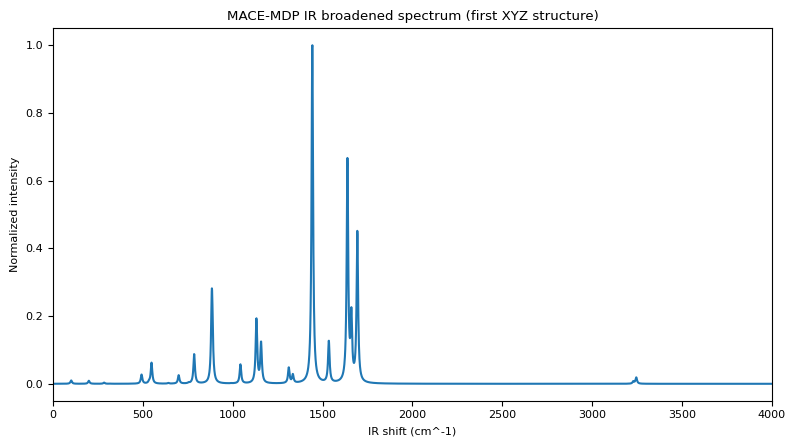

Wrote broadened spectrum: IR/results/first_structure_ir_broadened.csv


In [7]:
def broaden_spectrum_lorentzian(freqs, intens, fwhm=10.0, x_min=0.0, x_max=4000.0, step=1.0):
    x = np.arange(x_min, x_max + step, step, dtype=np.float64)
    gamma = 0.5 * fwhm
    spec = np.zeros_like(x)
    for f0, I in zip(freqs, intens):
        spec += I * (gamma / ((x - f0) ** 2 + gamma ** 2))
    return x, spec

x_cm1, spectrum = broaden_spectrum_lorentzian(freq_cm1, intensities)
if spectrum.max() > 0:
    spectrum = spectrum / spectrum.max()

broad_path = f"{out_dir}/first_structure_ir_broadened.csv"
pd.DataFrame({"cm1": x_cm1, "intensity": spectrum}).to_csv(broad_path, index=False)

plt.figure(figsize=(8, 4.5))
plt.plot(x_cm1, spectrum, lw=1.5)
plt.xlim(0, 4000)
plt.xlabel("IR shift (cm^-1)")
plt.ylabel("Normalized intensity")
plt.title("MACE-MDP IR broadened spectrum (first XYZ structure)")
plt.tight_layout()
plt.show()

print(f"Wrote broadened spectrum: {broad_path}")


## Interpreting the outputs

- `first_structure_ir_raw.csv`: mode-by-mode frequencies and raw IR activities.
- `first_structure_ir_broadened.csv`: smoothed, normalized curve for plotting/comparison.
- Strong peaks correspond to vibrations with large dipole derivatives.

If your environment uses GPU, set `device = "cuda"` and rerun all cells.
